<a href="https://colab.research.google.com/github/sayandatta888/Chasis_Vibration_Detection/blob/main/Vehicle_Vibrations_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 🚗 Smart Chassis Vibration Analysis System
## Detection of Structural Issues using Vibration Signal Processing


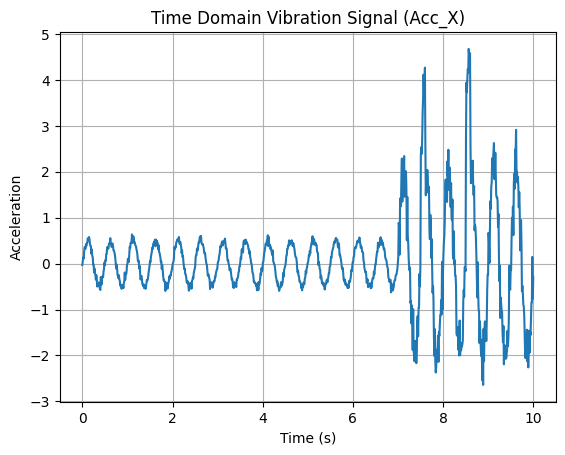

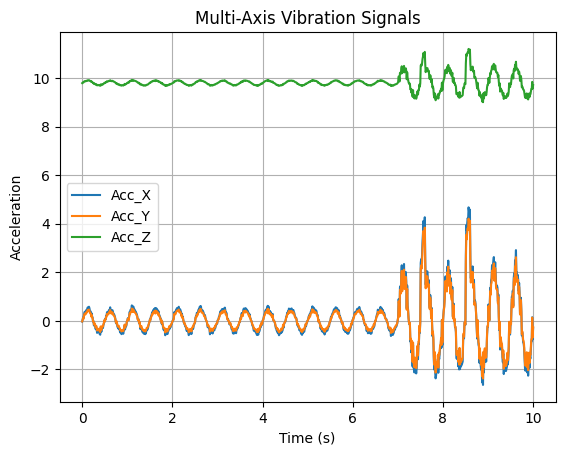


--- Acc_X Analysis ---
Amplitude: 4.675186324074982
RMS: 0.9925633899911824
Variance: 0.9823693047732238
🔴 CRITICAL: Structural issue detected for Acc_X

--- Acc_Y Analysis ---
Amplitude: 4.207667691667484
RMS: 0.884687801346272
Variance: 0.7803899233800092
🔴 CRITICAL: Structural issue detected for Acc_Y

--- Acc_Z Analysis ---
Amplitude: 11.202555897222496
RMS: 9.82022795253406
Variance: 0.08390447795861708
🔴 CRITICAL: Structural issue detected for Acc_Z


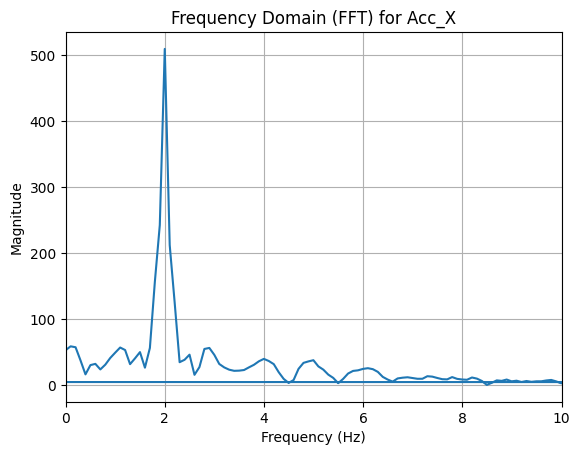

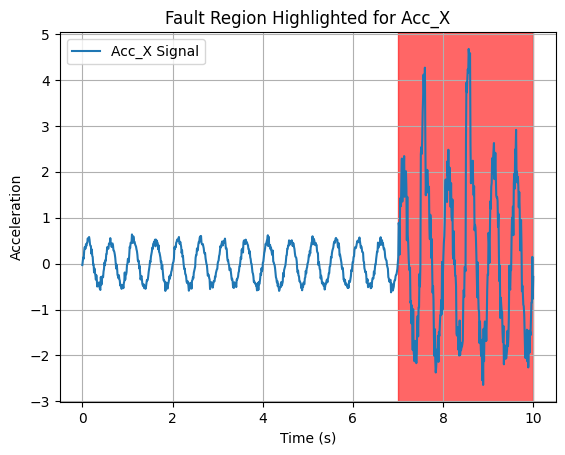

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("Vibration_Dataset.csv")

# Extract columns
time = df["Time"].values
acc_x = df["Acc_X"].values
acc_y = df["Acc_Y"].values
acc_z = df["Acc_Z"].values

# -----------------------------
# 1. Time Domain Graph (Acc_X)
# -----------------------------
plt.figure()
plt.plot(time, acc_x)
plt.title("Time Domain Vibration Signal (Acc_X)")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.grid()
plt.show()

# -----------------------------
# 2. Compare X, Y, Z Signals
# -----------------------------
plt.figure()
plt.plot(time, acc_x, label="Acc_X")
plt.plot(time, acc_y, label="Acc_Y")
plt.plot(time, acc_z, label="Acc_Z")
plt.title("Multi-Axis Vibration Signals")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 3. Feature Calculation and 4. Threshold-Based Detection for all axes
# -----------------------------

# Define thresholds
critical_amplitude_threshold = 2
critical_rms_threshold = 1.2
critical_variance_threshold = 0.8

moderate_amplitude_threshold = 1.5
moderate_rms_threshold = 0.8
moderate_variance_threshold = 0.5

axes_data = {
    "Acc_X": acc_x,
    "Acc_Y": acc_y,
    "Acc_Z": acc_z
}

for axis_name, acc_data in axes_data.items():
    print(f"\n--- {axis_name} Analysis ---")
    amplitude = np.max(np.abs(acc_data))
    rms = np.sqrt(np.mean(acc_data**2))
    variance = np.var(acc_data)

    print("Amplitude:", amplitude)
    print("RMS:", rms)
    print("Variance:", variance)

    if amplitude > critical_amplitude_threshold or rms > critical_rms_threshold or variance > critical_variance_threshold:
        print("🔴 CRITICAL: Structural issue detected for", axis_name)
    elif amplitude > moderate_amplitude_threshold or rms > moderate_rms_threshold or variance > moderate_variance_threshold:
        print("🟡 MODERATE: Vibration detected, further investigation recommended for", axis_name)
    else:
        print("✅ System Healthy for", axis_name)

# -----------------------------
# 5. FFT (Frequency Analysis)
# -----------------------------
fft_vals = np.fft.fft(acc_x)
fft_freq = np.fft.fftfreq(len(acc_x), d=time[1]-time[0])

plt.figure()
plt.plot(fft_freq, np.abs(fft_vals))
plt.title("Frequency Domain (FFT) for Acc_X")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 10)
plt.grid()
plt.show()

# -----------------------------
# 6. Highlight Fault Region
# -----------------------------
plt.figure()
plt.plot(time, acc_x, label="Acc_X Signal")

# highlight fault region (last 300 samples)
plt.axvspan(time[700], time[-1], color='red', alpha=0.6)

plt.title("Fault Region Highlighted for Acc_X")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.legend()
plt.grid()
plt.show()

In [11]:
max_amp_index = np.argmax(np.abs(acc_x))
time_at_max_amp = time[max_amp_index]

print(f"The maximum amplitude of Acc_X is {amplitude:.2f} and it occurs at approximately {time_at_max_amp:.2f} seconds.")

The maximum amplitude of Acc_X is 11.20 and it occurs at approximately 8.57 seconds.


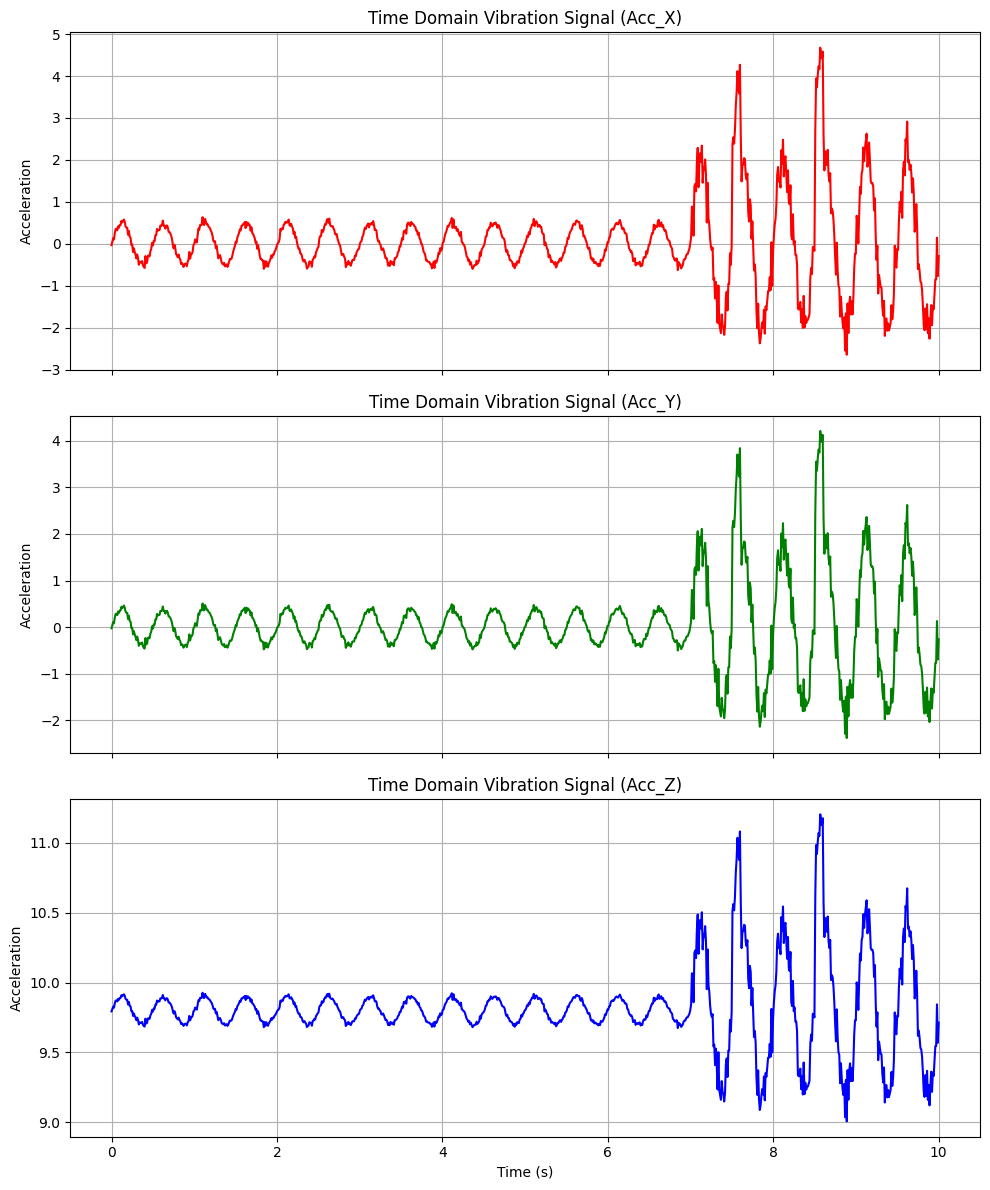

In [12]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Plot Acc_X
axes[0].plot(time, acc_x, color='red')
axes[0].set_title('Time Domain Vibration Signal (Acc_X)')
axes[0].set_ylabel('Acceleration')
axes[0].grid(True)

# Plot Acc_Y
axes[1].plot(time, acc_y, color='green')
axes[1].set_title('Time Domain Vibration Signal (Acc_Y)')
axes[1].set_ylabel('Acceleration')
axes[1].grid(True)

# Plot Acc_Z
axes[2].plot(time, acc_z, color='blue')
axes[2].set_title('Time Domain Vibration Signal (Acc_Z)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Acceleration')
axes[2].grid(True)

plt.tight_layout()
plt.show()